# Analiza podataka



U ovom projektu bavimo se problemom klasifikacije slika iz skupa Tiny ImageNet, koji sadrži 200 različitih klasa.
Cilj projekta je poređenje različitih savremenih arhitektura dubokog učenja i ispitivanje njihovih performansi na istom problemu klasifikacije.
U eksperimentima su korišćena tri modela: ConvNeXt-Tiny, Vision Transformer ViT-S/16 i Swin Transformer-Tiny.
ConvNeXt predstavlja savremenu konvolucionu arhitekturu, dok ViT-S/16 i Swin-T već imaju ugrađene self-attention mehanizme.
Na ovaj način porede se ConvNeXt-Tiny, ViT-S/16 i Swin-T, sa fokusom na tačnost klasifikacije, loss i vreme potrebno za treniranje.

Ova sveska namenjena je analizi podataka skupa Tiny ImageNet i pripremi podataka za eksperimente sa različitim modelima dubokog učenja. U okviru sveske analiziraju se struktura skupa podataka, broj klasa, broj slika po klasama, dimenzije slika i raspodela podataka između trening i validacionog skupa. Takođe se vrši vizuelizacija odabranih slika i osnovna statistička analiza kako bi se bolje razumele karakteristike dataseta pre početka treniranja modela. Za potrebe bržeg izvršavanja eksperimenata koristi se modifikovani skup podataka.

Učitavaju se biblioteke potrebne za obradu podataka, vizuelizaciju i treniranje modela.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
from PIL import Image
import os
import glob
from sklearn.manifold import TSNE


In [2]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


Definiše se uređaj za treniranje i funkcija za prebacivanje podataka na GPU ili CPU.

In [3]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def bind_gpu(data):
    device = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(data_elem) for data_elem in data]
    else:
        return data.to(device, non_blocking=True)

Podešavaju se parametri za učitavanje podataka, uključujući veličinu batch-a, nasumično mešanje podataka i način učitavanja tokom treniranja.

In [4]:
shuffle = True
num_workers = 8
pin_memory = False
BATCH_SIZE =  32
DATA_PATH_SUBSET = "tiny-imagenet-200-modified"
DATA_PATH = "tiny-imagenet-200"
IMG_SIZE=224

Definišu se transformacije koje se primenjuju na slike pre njihovog prosleđivanja modelu. Za trening se slike menjaju na zadatu veličinu, nasumično horizontalno okreću i dodatno augmentuju pomoću RandAugment-a, čime se povećava raznovrsnost podataka i smanjuje mogućnost preprilagođavanja modela. RandomErasing nasumično uklanja delove slike kako bi model postao otporniji na zaklonjene ili nedostajuće delove objekta. Nakon toga se slike pretvaraju u tenzore i normalizuju korišćenjem standardnih ImageNet srednjih vrednosti i standardnih devijacija. Za validaciju se koriste samo promena veličine, pretvaranje u tenzor i normalizacija, bez nasumičnih transformacija, kako bi se omogućila stabilna i objektivna procena performansi modela.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=27),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    ),
    transforms.RandomErasing(p=0.25)
])


val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

Učitavaju se originalni i smanjeni trening i validacioni skupovi, nakon čega se ispisuju broj klasa, broj slika u originalnim skupovima i broj slika u subset skupovima, čime se prikazuje koliko je podataka smanjeno radi bržeg izvršavanja eksperimenata. 

In [6]:
train_dataset_full = datasets.ImageFolder(
    root=f"{DATA_PATH}/train",
    transform=train_transform
)

val_dataset_full = datasets.ImageFolder(
    root=f"{DATA_PATH}/val",
    transform=val_transform
)

train_dataset = datasets.ImageFolder(
    root=f"{DATA_PATH_SUBSET}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATA_PATH_SUBSET}/val",
    transform=val_transform
)



Učitavaju se osnovne informacije o skupu podataka, uključujući broj klasa, broj trening i validacionih slika, veličinu subset skupova i originalne dimenzije slike, kao i podatke o prvoj slici, njenom obliku, tipu podataka i pripadajućoj klasi.

In [7]:
image_path, label = train_dataset.samples[0]
img = Image.open(image_path)
IMG_SIZE = img.size
NUM_CLASSES = len(train_dataset_full.classes)

print("Broj klasa:",NUM_CLASSES)
print("Broj trening slika:", len(train_dataset_full))
print("Broj validacionih slika:", len(val_dataset_full))
print("Broj slika u subset trening skupu:", len(train_dataset))
print("Broj slika u subset validacionom skupu:", len(val_dataset))
print("Originalna veličina slike:", IMG_SIZE)
print(f"Klasa prve slike: {train_dataset.classes[label]}")

Broj klasa: 200
Broj trening slika: 100000
Broj validacionih slika: 10000
Broj slika u subset trening skupu: 95000
Broj slika u subset validacionom skupu: 10000
Originalna veličina slike: (64, 64)
Klasa prve slike: n01443537


Prikazuju se dimenzije prve slike nakon primene transformacija, uključujući broj kanala, visinu i širinu slike.



In [8]:
first_image, _ = train_dataset[0]
first_size = first_image.shape


print("Dimenzije slike (kanali, visina, širina):", first_image.shape)
print("Visina slike:", first_image.shape[1], "piksela")
print("Širina slike:", first_image.shape[2], "piksela")
print("Broj kanala:", first_image.shape[0])



Dimenzije slike (kanali, visina, širina): torch.Size([3, 224, 224])
Visina slike: 224 piksela
Širina slike: 224 piksela
Broj kanala: 3


Prikazuje se po jedna reprezentativna slika iz prvih 20 klasa redukovanog skupa podataka, pri čemu se slike prikazuju zajedno sa nazivom pripadajuće klase. Na ovaj način se vizuelno proverava raznovrsnost i sadržaj slika, kao i razlike između različitih klasa

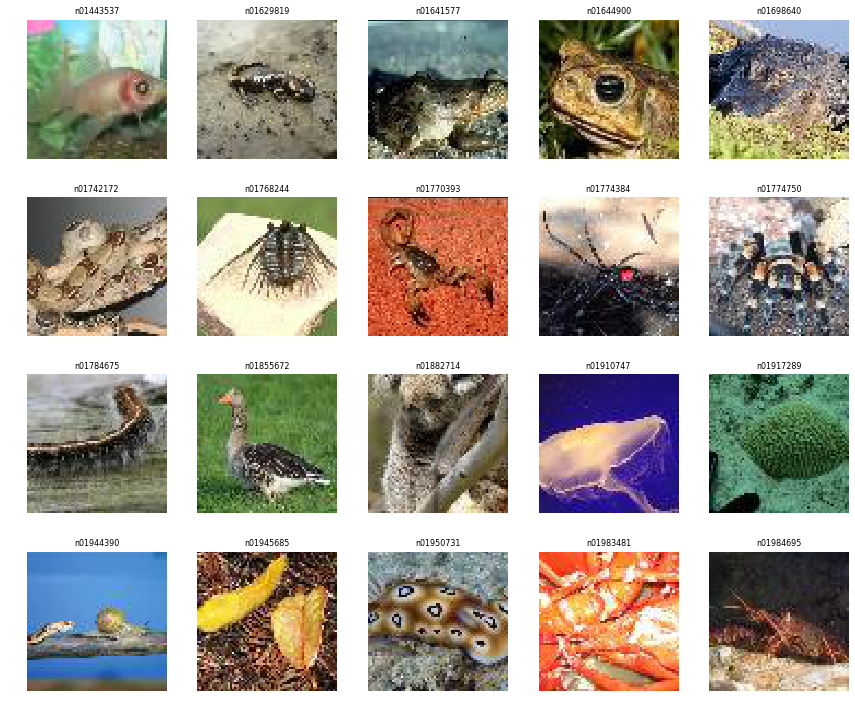

In [9]:

images = []
names = []

for class_idx in range(20):

    class_name = train_dataset.classes[class_idx]

    files = glob.glob(
        f"tiny-imagenet-200-modified/train/{class_name}/images/*"
    )

    img = Image.open(files[0]).convert("RGB")
    img = img.resize((64, 64))

    images.append(np.array(img))
    names.append(class_name)

plt.figure(figsize=(12, 10))

for i in range(20):

    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])
    plt.title(names[i], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

Analizira se raspodela slika po klasama kako bi se proverilo da li je skup podataka balansiran. Prikazuju se ukupan broj klasa, ukupan broj slika, kao i minimalan i maksimalan broj slika po klasi. Na osnovu dobijenih vrednosti utvrđuje se da li svaka klasa sadrži jednak broj slika, što je važno za pouzdanu obuku i objektivnu evaluaciju modela.

In [10]:
class_counts = Counter(train_dataset.targets)

print("Broj klasa:", len(class_counts))
print("Ukupan broj slika:", len(train_dataset))
print("Minimum slika po klasi:", min(class_counts.values()))
print("Maximum slika po klasi:", max(class_counts.values()))

if len(set(class_counts.values())) == 1:
    print("Dataset je balansiran.")
else:
    print("Dataset nije balansiran.")

Broj klasa: 200
Ukupan broj slika: 95000
Minimum slika po klasi: 475
Maximum slika po klasi: 475
Dataset je balansiran.


Vizuelizuje se raspodela broja slika po klasama pomoću stubičastog grafikona, čime se omogućava lak pregled zastupljenosti svake klase u trening skupu. Grafikon takođe olakšava uočavanje eventualne neuravnoteženosti između klasa.

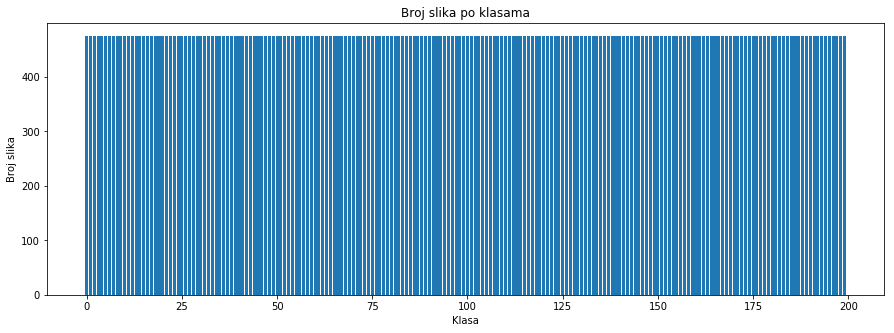

In [11]:
plt.figure(figsize=(15, 5))

plt.bar(range(len(class_counts)),class_counts.values())
plt.xlabel("Klasa")
plt.ylabel("Broj slika")
plt.title("Broj slika po klasama")

plt.show()

t-SNE se koristi za vizuelnu analizu strukture skupa podataka, odnosno za prikaz sličnosti između slika u dvodimenzionalnom prostoru. Pošto su slike složeni podaci velikog broja dimenzija, t-SNE ih projektuje u 2D prostor kako bi se lakše uočilo da li se slike različitih klasa grupišu, koliko su klase međusobno slične i da li postoje preklapanja između njih. Ova analiza omogućava bolje razumevanje strukture i sličnosti klasa pre treniranja modela i poređenja različitih arhitektura.

Definišu se transformacije i učitava se subset trening skupa za t-SNE analizu, pri čemu se slike stavljaju na dimenziju 64×64 i pretvaraju u tenzore. Nakon učitavanja prikazuju se broj klasa i ukupan broj slika koje su dostupne za analizu.

In [12]:
IMG_SIZE_TSNE = 64

tsne_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_TSNE, IMG_SIZE_TSNE)),
    transforms.ToTensor()
])

tsne_dataset = datasets.ImageFolder(
    root=f"{DATA_PATH}/train",
    transform=tsne_transform
)

print("Broj klasa:", len(tsne_dataset.classes))
print("Ukupan broj slika:", len(tsne_dataset))

Broj klasa: 200
Ukupan broj slika: 100000


Pripremaju se slike iz t-SNE skupa tako što se pretvaraju u numeričke vektore pogodne za analizu, pri čemu se RGB slike pretvaraju u grayscale i izravnavaju u jednodimenzionalne vektore. Dobijeni vektori se čuvaju u matrici X, dok se njihove pripadajuće klase čuvaju u y, nakon čega se prikazuju broj analiziranih slika, broj klasa i broj karakteristika po slici. Za prikaz je uzeto 10 klasa, i iz svake klase po 100 slika

In [13]:
X = []
y = []

num_classes = 10
images_per_class = 100
class_counts = {i: 0 for i in range(num_classes)}

for i in range(len(tsne_dataset)):
    image, label = tsne_dataset[i]

    if label >= num_classes:
        continue

    if class_counts[label] >= images_per_class:
        continue

    image = image.permute(1, 2, 0).numpy()
    image = image.mean(axis=2)
    image = image.flatten()

    X.append(image)
    y.append(label)

    class_counts[label] += 1

    if all(count == images_per_class for count in class_counts.values()):
        break

X = np.array(X)
y = np.array(y)

print("Broj slika:", len(X))
print("Broj klasa:", len(np.unique(y)))
print("Dimenzija slike:", X.shape[1])


Broj slika: 1000
Broj klasa: 10
Dimenzija slike: 4096


Primjenjuje se t-SNE algoritam za smanjenje dimenzionalnosti slika na dve dimenzije, pri čemu se podešavaju parametri metode kako bi se očuvala sličnost između podataka. Dobijene dvodimenzionalne reprezentacije čuvaju se u X_tsne i koriste se za kasniju vizuelizaciju strukture i grupisanja klasa.

In [16]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)
X_tsne = tsne.fit_transform(X)


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


Vizuelizuje se t-SNE projekcija uzeti 10 klasa u dvodimenzionalnom prostoru, pri čemu se svaka klasa prikazuje različitom bojom kako bi se lakše uočila grupisanja, sličnosti i preklapanja između klasa. Na osnovu ovog prikaza može se proceniti koliko su pojedine klase međusobno razdvojene u prostoru karakteristika.

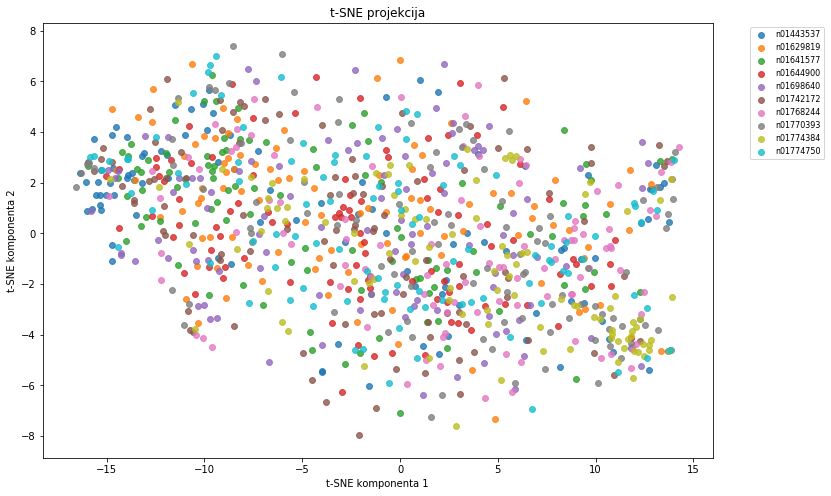

In [17]:
plt.figure(figsize=(12, 8))

for class_idx in range(10):

    mask = y == class_idx

    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=35,
        alpha=0.8,
        label=tsne_dataset.classes[class_idx]
    )

plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")

plt.title(
    "t-SNE projekcija"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.show()